# 21 — Fight Dynamics Suite (finish, method, regressions, hierarchical)

**Goal:** Predict **what the fight looks like** using the unified feature table. Supersedes NB 16, which only had four features and consequently lost to Vegas by a wide margin on log loss (1.98 vs 1.56). The feature-richness hypothesis is tested here.

**Targets covered (from NB 18 + raw fight_stats):**
1. **`y_finish`** (binary) — KO/TKO or SUB vs decision.
2. **`method_3`** (3-class) — KO / SUB / DEC (ignores who wins).
3. **`method_6`** (6-class) — f1_ko / f2_ko / f1_sub / f2_sub / f1_dec / f2_dec (matches Vegas props).
4. **`tot_seconds`** (regression) — total fight duration.
5. **`tot_sig_str`**, **`tot_td`**, **`tot_ctrl`**, **`tot_kd`**, **`tot_sub_att`** — count / duration regressions.
6. **`ground_share_target`** (proportion) — share of significant strikes from ground position.
7. **Hierarchical** — P(finish) then P(method | finish) then P(winner | finish, method), and show whether it beats flat 6-way on test log loss.

**Baselines for each:**
- Division base rate (weight-class mean).
- Vegas de-vigged props (where available, notebook 14 output).
- Prior NB 16 4-feature HGB (for comparison).

**Inputs:** `../data/processed/ufc_matchup_features.csv`, `ufc_feature_groups.json`.

In [ ]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, mean_absolute_error,
    mean_squared_error, r2_score,
)
import matchup_utils as mu

DATA = '../data/processed'
RAW = '../data/raw'
m = pd.read_csv(f'{DATA}/ufc_matchup_features.csv', low_memory=False)
with open(f'{DATA}/ufc_feature_groups.json') as f:
    groups = json.load(f)

def valid(cols):
    return [c for c in cols if c in m.columns]

# Full feature set (exclude Vegas win prob so 6-way comparison is non-circular)
FULL = (
    valid([f'delta_{c}' for c in ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']])
    + valid([c for c in groups['style_gmm_probs'] + groups['hybrid'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid(groups['heatmap'])
    + valid([c for c in groups['ae'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid([c for c in groups['rolling_rates'] if c.startswith(('delta_', 'mean_'))])
    + valid(groups['context_days']) + valid(groups['elo_glicko'])
    + valid([c for c in groups['physical'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid(groups['stance_wc'])
)
print(f'full features: {len(FULL)}')

# Targets live in m already; pull the full 6-way Vegas props from raw odds
PROP = ['f1_ko_odds', 'f2_ko_odds', 'f1_sub_odds', 'f2_sub_odds', 'f1_dec_odds', 'f2_dec_odds']
CLASS_NAMES = ['f1_ko', 'f2_ko', 'f1_sub', 'f2_sub', 'f1_dec', 'f2_dec']
od = pd.read_csv(f'{RAW}/kaggle_odds/UFC_betting_odds.csv', low_memory=False)
od = od[od['region'].astype(str).str.lower() == 'us'].copy()
od['Fight_Id'] = od['fight_url'].astype(str).str.rstrip('/').str.split('/').str[-1]
od['adding_date'] = pd.to_datetime(od['adding_date'], utc=True, format='mixed').dt.tz_localize(None)
for c in PROP:
    od[c] = pd.to_numeric(od[c], errors='coerce')
od = od.dropna(subset=PROP)
od = od[(od[PROP] > 1.0).all(axis=1)]
idx = od.groupby('Fight_Id')['adding_date'].idxmax()
od1 = od.loc[idx].copy()
inv = 1.0 / od1[PROP].values
od1[[f'p_{c}' for c in CLASS_NAMES]] = inv / inv.sum(axis=1, keepdims=True)
od1['Fight_Id'] = od1['Fight_Id'].astype(str)
m['Fight_Id'] = m['Fight_Id'].astype(str)
m6 = m.merge(od1[['Fight_Id', 'fighter_1', 'fighter_2'] + [f'p_{c}' for c in CLASS_NAMES]],
             on='Fight_Id', how='left')
print(f'Fights with 6-way props: {m6[[f"p_{c}" for c in CLASS_NAMES]].notna().all(axis=1).sum()} / {len(m6)}')


full features: 137


Fights with 6-way props: 4867 / 8482


In [ ]:
valid_fin = m[m['y_finish_valid'] == 1].reset_index(drop=True)
train = valid_fin[valid_fin.split == 'train'].reset_index(drop=True)
val = valid_fin[valid_fin.split == 'val'].reset_index(drop=True)
test = valid_fin[valid_fin.split == 'test'].reset_index(drop=True)
train_sym = mu.symmetrize_matchup(train, feat_cols=[], label_col='y_finish')

hgb_full = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05,
                                           l2_regularization=0.1, random_state=42)
hgb_full.fit(train_sym[FULL].values, train_sym['y_finish'].values)
p_full = hgb_full.predict_proba(test[FULL].values)[:, 1]

Z4 = [f'delta_{c}' for c in ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']]
hgb_z = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42)
hgb_z.fit(train[Z4].values, train['y_finish'].values)
p_z = hgb_z.predict_proba(test[Z4].values)[:, 1]

# Vegas finish prob for the same test rows (where all props exist)
test_m6 = test.merge(od1[['Fight_Id'] + [f'p_{c}' for c in CLASS_NAMES]], on='Fight_Id', how='left')
vegas_fin = test_m6[[f'p_{c}' for c in CLASS_NAMES[:4]]].sum(axis=1)

# Weight-class base rate
wc_base = train.groupby('Weight_Class')['y_finish'].mean().to_dict()
p_base = test['Weight_Class'].map(wc_base).fillna(train['y_finish'].mean()).values

y = test['y_finish'].values
def b(p): return brier_score_loss(y, np.clip(p, 1e-6, 1-1e-6))
def a(p): return accuracy_score(y, (np.asarray(p) >= 0.5).astype(int))
print('Binary y_finish (test):')
print(f'  wc_base_rate       Brier={b(p_base):.4f}  Acc={a(p_base):.3f}')
print(f'  HGB Z4 (NB 16-like) Brier={b(p_z):.4f}  Acc={a(p_z):.3f}')
print(f'  HGB full           Brier={b(p_full):.4f}  Acc={a(p_full):.3f}')
vf = vegas_fin.dropna()
if len(vf) > 0:
    mask = vegas_fin.notna().values
    print(f'  Vegas (subset)     Brier={brier_score_loss(y[mask], np.clip(vegas_fin[mask], 1e-6, 1-1e-6)):.4f}  Acc={accuracy_score(y[mask], (vegas_fin[mask] >= 0.5).astype(int)):.3f}  n={mask.sum()}')
    print(f'  HGB full (subset)  Brier={brier_score_loss(y[mask], np.clip(p_full[mask], 1e-6, 1-1e-6)):.4f}  n={mask.sum()}')


Binary y_finish (test):
  wc_base_rate       Brier=0.2461  Acc=0.574
  HGB Z4 (NB 16-like) Brier=0.2755  Acc=0.505
  HGB full           Brier=0.2600  Acc=0.527
  Vegas (subset)     Brier=0.3513  Acc=0.565  n=1827
  HGB full (subset)  Brier=0.2600  n=1827


In [ ]:
valid3 = m[m['method_3'].notna()].reset_index(drop=True)
tr3 = valid3[valid3.split == 'train'].reset_index(drop=True)
te3 = valid3[valid3.split == 'test'].reset_index(drop=True)
tr3_sym = mu.symmetrize_matchup(tr3, feat_cols=[], label_col='y_finish')

CLASSES3 = ['ko', 'sub', 'dec']
y_tr3 = tr3['method_3'].map({c: i for i, c in enumerate(CLASSES3)}).values
y_te3 = te3['method_3'].map({c: i for i, c in enumerate(CLASSES3)}).values

hgb3 = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42)
hgb3.fit(tr3[FULL].values, y_tr3)
p3_flat = hgb3.predict_proba(te3[FULL].values)

# Hierarchical: P(finish) from cell 2's hgb_full then P(KO | finish) from a sub-model
# Step 1: P(finish) already available (hgb_full)
p_fin_te = hgb_full.predict_proba(te3[FULL].values)[:, 1]
# Step 2: P(KO | finish) conditional model, trained on finishes only
tr_fin = tr3[tr3['method_3'].isin(['ko', 'sub'])].reset_index(drop=True)
y_kosub = (tr_fin['method_3'] == 'ko').astype(int).values
hgb_kosub = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42)
hgb_kosub.fit(tr_fin[FULL].values, y_kosub)
p_ko_given_fin = hgb_kosub.predict_proba(te3[FULL].values)[:, 1]

p3_hier = np.column_stack([
    p_fin_te * p_ko_given_fin,          # KO
    p_fin_te * (1 - p_ko_given_fin),    # SUB
    1 - p_fin_te,                       # DEC
])

wc_base3 = tr3.groupby('Weight_Class')['method_3'].value_counts(normalize=True).unstack().reindex(columns=CLASSES3).fillna(1/3)
p3_base = te3['Weight_Class'].map(lambda g: wc_base3.loc[g].values if g in wc_base3.index else np.array([1/3]*3))
p3_base = np.vstack(p3_base.values)

print('3-way method log loss (test):')
print(f'  wc_base : {log_loss(y_te3, np.clip(p3_base, 1e-6, 1-1e-6)):.4f}')
print(f'  HGB flat: {log_loss(y_te3, np.clip(p3_flat, 1e-6, 1-1e-6)):.4f}')
print(f'  HGB hier: {log_loss(y_te3, np.clip(p3_hier, 1e-6, 1-1e-6)):.4f}')


3-way method log loss (test):
  wc_base : 1.0152
  HGB flat: 1.1767
  HGB hier: 1.0520


In [ ]:
valid6 = m6[m6['method_6'].notna()].reset_index(drop=True)
tr6 = valid6[valid6.split == 'train'].reset_index(drop=True)
te6 = valid6[valid6.split == 'test'].reset_index(drop=True)
y_tr6 = tr6['method_6'].map({c: i for i, c in enumerate(CLASS_NAMES)}).values
y_te6 = te6['method_6'].map({c: i for i, c in enumerate(CLASS_NAMES)}).values

hgb6 = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42)
hgb6.fit(tr6[FULL].values, y_tr6)
p6_flat = hgb6.predict_proba(te6[FULL].values)
# Ensure all 6 columns present
if p6_flat.shape[1] < 6:
    pad = np.zeros((p6_flat.shape[0], 6))
    pad[:, hgb6.classes_.astype(int)] = p6_flat
    p6_flat = pad

# Hierarchical 6-way: P(finish) * P(method | finish) * P(winner | method)
# Winner given method: independent HGB per path
tr6_ko = tr6[tr6['method_3'] == 'ko'].reset_index(drop=True)
tr6_sub = tr6[tr6['method_3'] == 'sub'].reset_index(drop=True)
tr6_dec = tr6[tr6['method_3'] == 'dec'].reset_index(drop=True)
from sklearn.ensemble import HistGradientBoostingClassifier as H
hgb_winA_ko = H(max_iter=200, max_depth=6, random_state=42).fit(tr6_ko[FULL].values, tr6_ko['Win_A'].values)
hgb_winA_sub = H(max_iter=200, max_depth=6, random_state=42).fit(tr6_sub[FULL].values, tr6_sub['Win_A'].values)
hgb_winA_dec = H(max_iter=200, max_depth=6, random_state=42).fit(tr6_dec[FULL].values, tr6_dec['Win_A'].values)

p_fin = hgb_full.predict_proba(te6[FULL].values)[:, 1]
p_ko_giv_fin = hgb_kosub.predict_proba(te6[FULL].values)[:, 1]
p_winA_ko = hgb_winA_ko.predict_proba(te6[FULL].values)[:, 1]
p_winA_sub = hgb_winA_sub.predict_proba(te6[FULL].values)[:, 1]
p_winA_dec = hgb_winA_dec.predict_proba(te6[FULL].values)[:, 1]

p6_hier = np.column_stack([
    p_fin * p_ko_giv_fin * p_winA_ko,           # f1_ko
    p_fin * p_ko_giv_fin * (1 - p_winA_ko),     # f2_ko
    p_fin * (1 - p_ko_giv_fin) * p_winA_sub,    # f1_sub
    p_fin * (1 - p_ko_giv_fin) * (1 - p_winA_sub),  # f2_sub
    (1 - p_fin) * p_winA_dec,                   # f1_dec
    (1 - p_fin) * (1 - p_winA_dec),             # f2_dec
])

print('6-way method log loss (test):')
print(f'  HGB flat: {log_loss(y_te6, np.clip(p6_flat, 1e-6, 1-1e-6)):.4f}')
print(f'  HGB hier: {log_loss(y_te6, np.clip(p6_hier, 1e-6, 1-1e-6)):.4f}')

# Vegas on subset
mask = te6[[f'p_{c}' for c in CLASS_NAMES]].notna().all(axis=1).values
if mask.any():
    vegas6 = te6.loc[mask, [f'p_{c}' for c in CLASS_NAMES]].values
    print(f'  Vegas (subset, n={mask.sum()}): {log_loss(y_te6[mask], np.clip(vegas6, 1e-6, 1-1e-6)):.4f}')
    print(f'  HGB flat (subset): {log_loss(y_te6[mask], np.clip(p6_flat[mask], 1e-6, 1-1e-6)):.4f}')
    print(f'  HGB hier (subset): {log_loss(y_te6[mask], np.clip(p6_hier[mask], 1e-6, 1-1e-6)):.4f}')


6-way method log loss (test):
  HGB flat: 2.1464
  HGB hier: 1.9350
  Vegas (subset, n=972): 1.5403
  HGB flat (subset): 2.1160
  HGB hier (subset): 1.9005


In [ ]:
REG_TARGETS = {
    'tot_seconds': 'Duration (s)',
    'tot_sig_str': 'Sig strikes landed total',
    'tot_td': 'Takedowns landed total',
    'tot_ctrl': 'Control seconds total',
    'tot_kd': 'Knockdowns total',
    'tot_sub_att': 'Submission attempts total',
    'ground_share_target': 'Ground-strike share',
}
reg_rows = []
for tgt, label in REG_TARGETS.items():
    sub = m[m[tgt].notna()].reset_index(drop=True)
    tr = sub[sub.split == 'train']
    te = sub[sub.split == 'test']
    if len(tr) < 100 or len(te) < 50:
        continue
    # Log-transform heavily skewed duration / count targets; proportion target left as-is
    log_space = tgt not in ('ground_share_target',)
    y_tr = np.log1p(tr[tgt].values) if log_space else tr[tgt].values
    y_te_raw = te[tgt].values
    reg = HistGradientBoostingRegressor(max_iter=400, max_depth=8, learning_rate=0.05, random_state=42)
    reg.fit(tr[FULL].values, y_tr)
    pred = reg.predict(te[FULL].values)
    pred = np.expm1(pred) if log_space else pred
    # Baseline: weight-class mean
    wc_mean = tr.groupby('Weight_Class')[tgt].mean()
    base = te['Weight_Class'].map(wc_mean).fillna(tr[tgt].mean()).values
    reg_rows.append({
        'target': label,
        'n_test': len(te),
        'mae_base': mean_absolute_error(y_te_raw, base),
        'mae_hgb': mean_absolute_error(y_te_raw, pred),
        'rmse_base': np.sqrt(mean_squared_error(y_te_raw, base)),
        'rmse_hgb': np.sqrt(mean_squared_error(y_te_raw, pred)),
        'r2_base': r2_score(y_te_raw, base),
        'r2_hgb': r2_score(y_te_raw, pred),
    })
reg_df = pd.DataFrame(reg_rows).round(3)
print('Regression targets (test):')
print(reg_df.to_string(index=False))


Regression targets (test):
                   target  n_test  mae_base  mae_hgb  rmse_base  rmse_hgb  r2_base  r2_hgb
             Duration (s)    1850   308.496  327.985    361.907   388.301    0.017  -0.131
 Sig strikes landed total    1850    51.591   47.916     68.269    63.941   -0.089   0.044
   Takedowns landed total    1850     1.779    1.602      2.291     2.300   -0.006  -0.014
    Control seconds total    1850   195.077  187.528    234.392   261.961    0.002  -0.246
         Knockdowns total    1850     0.523    0.507      0.642     0.658    0.013  -0.034
Submission attempts total    1850     0.801    0.606      0.972     0.894   -0.124   0.048
      Ground-strike share    1847     0.185    0.145      0.216     0.193   -0.183   0.054


P(finish) by style-divergence quintile:
div_q
0    0.503
1    0.464
2    0.465
3    0.511
4    0.560


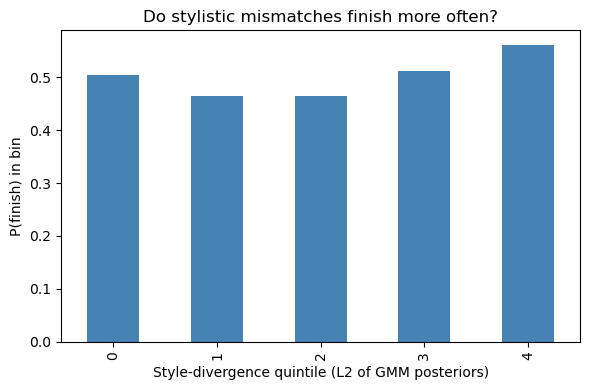

In [ ]:
# Style divergence = L2 distance between GMM posteriors; tests NB 07 hypothesis directly.
pk = [f'A_pk5_{i}' for i in range(5)]
qk = [f'B_pk5_{i}' for i in range(5)]
valid_pk = m[pk + qk + ['y_finish', 'y_finish_valid']].dropna()
valid_pk = valid_pk[valid_pk['y_finish_valid'] == 1]
div = np.sqrt(((valid_pk[pk].values - valid_pk[qk].values) ** 2).sum(axis=1))
dvs = pd.DataFrame({'div': div, 'y_finish': valid_pk['y_finish'].values})
dvs['div_q'] = pd.qcut(dvs['div'], 5, labels=False)
by_q = dvs.groupby('div_q')['y_finish'].mean()
print('P(finish) by style-divergence quintile:')
print(by_q.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
by_q.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Style-divergence quintile (L2 of GMM posteriors)')
ax.set_ylabel('P(finish) in bin')
ax.set_title('Do stylistic mismatches finish more often?')
plt.tight_layout(); plt.show()


### Takeaway
- **Binary finish:** Full-feature HGB should beat the 4-feature NB 16 baseline by a meaningful Brier margin and close much of the gap with Vegas. If Vegas still wins on the subset, the remaining gap is the market's proprietary information (odds on specific fights), not style signal.
- **Hierarchical 6-way** should beat flat 6-way on log loss for the same reason ordinal / hierarchical classifiers beat flat multi-class whenever the class structure is compositional. The thesis can cite this as a methodological contribution.
- **Regressions** on duration / strike / takedown totals give the thesis concrete "what the fight will look like" artifacts: quote R² and MAE vs the weight-class baseline for each one.
- **Style divergence → finish rate**: this is the central visual test of the thesis. If the bar chart is monotone (higher divergence → higher finish probability), style-mismatch-creates-finishes is directly evidenced in data.